# Amplitude Rabi Experiment — NV Center (ISTA Baykusheva Lab)

This notebook implements an **Amplitude Rabi** experiment on a nitrogen-vacancy (NV) center
using a Zurich Instruments HDAWG8 and the LabOne Q framework.

**Physical sequence per sweep step:**
```
 t=0          4µs          6µs   8µs      10µs
  |            |            |     |         |
AOM  ▓▓▓▓▓▓▓▓▓▓            ▓▓▓▓▓▓▓
TTU                ▓▓▓▓▓▓▓▓▓▓
 MW           ▓ (100 ns MW π-pulse, amplitude swept)
```
- **AOM** — Laser gating: initialises the NV spin state and provides readout
- **TTU** — External trigger (e.g. time-tagger or delay unit)
- **MW** — Microwave drive pulse whose amplitude is swept to find the π-pulse

**Hardware:** HDAWG8 DEV8297 | Data server: `10.42.193.4:8004`

**Requirements:** LabOne Q >= 25.10, HDAWG8/CNT/ME/MF/PC option

## 1. Imports

Import LabOne Q and helper utilities.
`laboneq.simple` exposes the full public API through a single wildcard import.

In [19]:
# LabOne Q:
from laboneq.simple import *
# pretty printing
from pprint import pprint
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
import numpy as np

## 2. Device Setup

Define the hardware topology and signal calibration.

LabOne Q requires a **`DeviceSetup`** that maps physical instrument ports to named
**logical signals**. Three logical signals are used here:

| Logical signal | HDAWG port | Function |
|---|---|---|
| `q0 / AOM_line` | SIGOUTS/0 | AOM gate (laser) |
| `q1 / TTU_line` | SIGOUTS/1 | Trigger / time-tagger unit |
| `q2 / MW_line`  | SIGOUTS/2 | Microwave π-pulse |


### 2a. (Optional) Descriptor-based setup

The `create_device_setup` helper below can load a YAML descriptor file as an
alternative to the programmatic setup in section 2b. It is not used in the current
workflow but is kept for reference.

In [20]:
def create_device_setup(descriptor):
    device_setup=DeviceSetup.from_descriptor(descriptor, server_host="10.42.193.4",server_port="8004",setup_name="myFirstSetup")
    #calibrate_devices(device_setup)

    return device_setup

### 2b. Signal calibration

Each signal line is calibrated with an **oscillator** and modulation type:

| Signal | Oscillator freq | Modulation |
|---|---|---|
| AOM_line | 10 MHz | HARDWARE |
| TTU_line | 10 MHz | HARDWARE |
| MW_line  | 200 MHz | HARDWARE |

`ModulationType.HARDWARE` means the HDAWG itself performs the IQ up-conversion
on the output channel — no software envelope modulation is applied.

In [21]:
def calibrate_devices(device_setup):
    device_setup.logical_signal_groups["q0"].logical_signals["AOM_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid="drive_AOM", frequency=10e6, modulation_type=ModulationType.HARDWARE
        ),
        mixer_calibration=MixerCalibration(
            voltage_offsets=[0.0, 0.0],
            correction_matrix=[
                [1.0, 0.0],
                [0.0, 1.0],
            ],
        ),
    )
    
    device_setup.logical_signal_groups["q1"].logical_signals["TTU_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid = "drive_TTU", frequency=10e6, modulation_type=ModulationType.HARDWARE
        ),)
    
    device_setup.logical_signal_groups["q2"].logical_signals["MW_line"].calibration = SignalCalibration(
        oscillator=Oscillator(
            uid = "drive_MW", frequency=200e6, modulation_type=ModulationType.HARDWARE
        ),)
        

### 2c. Instantiate the device setup

Build the `DeviceSetup` programmatically, connect it to the data server at
`10.42.193.4:8004`, and apply the calibration.

In [22]:
# create device setup
my_device_setup = DeviceSetup("my_device_setup")
my_device_setup.add_dataserver(host = "10.42.193.4", port = "8004")

# add instruments
my_device_setup.add_instruments(HDAWG(uid="device_hdawg", address="dev8297",device_options='HDAWG8/CNT/ME/MF/PC'))

# add connections
my_device_setup.add_connections(
    "device_hdawg",
    create_connection(to_signal="q0/AOM_line", ports=["SIGOUTS/0"], type='rf'),
    create_connection(to_signal="q1/TTU_line", ports=["SIGOUTS/1"], type='rf'),
    create_connection(to_signal="q2/MW_line", ports=["SIGOUTS/2"], type='rf'),
)

# set baseline calibration
calibrate_devices(my_device_setup)

### 2d. Connect session

Open a LabOne Q `Session` and connect to the physical instrument.
Set `do_emulation=True` to run offline without hardware.

In [24]:
#device_setup=create_device_setup(descriptor)
session=Session(device_setup=my_device_setup)
session.connect(do_emulation=True, ignore_version_mismatch=True)

[2026.05.06 15:36:21.869] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Supports/ISTA-Baykusheva/L1QScripts/laboneq_output/log
[2026.05.06 15:36:21.870] INFO    VERSION: laboneq 26.4.0
[2026.05.06 15:36:21.870] INFO    Connecting to data server at 10.42.193.4:8004
[2026.05.06 15:36:21.871] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.0.940 at 10.42.193.4:8004
[2026.05.06 15:36:21.873] INFO    Configuring the device setup
[2026.05.06 15:36:21.874] INFO    The device setup is configured


## 3. Sweep Parameter

Define the amplitude sweep for the MW π-pulse.

A `LinearSweepParameter` creates a linearly spaced array of values that LabOne Q
will iterate over in real-time on the HDAWG sequencer — no host-loop required.

| Parameter | Value |
|---|---|
| Start amplitude | 0.1 (10 % of full scale) |
| Stop amplitude  | 1.0 (100 % of full scale) |
| Number of points | 5 |

> **Tip:** Increase `count` to 20–50 points for a well-resolved Rabi oscillation.

In [25]:
amplitude_sweep = LinearSweepParameter(
    uid="amplitude",
    start = 0.1,
    stop = 1.0,
    count = 5
)

## 4. Experiment Definition

The `amplitude_rabi` function builds the LabOne Q `Experiment` object.

**Loop structure:**
```
acquire_loop_rt  (CYCLIC averaging, INTEGRATION acquisition)
  └── sweep over amplitude
        ├── section AOM   (10 µs, LEFT-aligned)
        ├── section TTU   (10 µs, LEFT-aligned)
        └── section MW    (10 µs, LEFT-aligned)
```

All three sections are `10 µs` long and run **in parallel** (no `play_after` dependency).

**Section timing detail:**

| Section | t = 0 | Duration | Notes |
|---|---|---|---|
| AOM | const pulse | 4 µs | Laser init / spin polarisation |
| AOM | delay | 2 µs | Gap between laser pulses |
| AOM | const pulse | 2 µs | Readout window |
| TTU | delay | 5 µs | Waiting for MW pulse |
| TTU | const pulse | 2 µs | Trigger to external unit |
| MW  | delay | 4 µs | Wait for laser init to finish |
| MW  | gaussian | 100 ns | MW π-pulse (amplitude = sweep param) |
| MW  | delay | 100 ns | Guard time after MW pulse |

All pulses use `marker1` to output a digital marker on the HDAWG marker output,
which can be used to gate external instruments (e.g. SPD, time tagger).

In [26]:
def amplitude_rabi(amplitude_sweep):

    exp_rabi=Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("AOM"),
            ExperimentSignal("TTU"),
            ExperimentSignal("MW"),
        ],
    )

    with exp_rabi.acquire_loop_rt(
        count = 1,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type = AcquisitionType.INTEGRATION,
    ):
        with exp_rabi.sweep( uid ='sweep',
                        parameter= amplitude_sweep
                        ):
            # section 1: Play the trigger#1 to the laser
                
            with exp_rabi.section(
                uid="AOM",
                alignment=SectionAlignment.LEFT,
                length=10e-6,
                ):
                exp_rabi.play(
                    signal="AOM",
                    pulse=pulse_library.const(length=4000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                    )
                
                exp_rabi.delay(signal="AOM",time=2000e-9)

                exp_rabi.play(
                    signal="AOM",
                    pulse=pulse_library.const(length=2000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                )


            with exp_rabi.section(
                uid="TTU",
                alignment=SectionAlignment.LEFT,
                length=10e-6, 
                #trigger={"drive":{"state":1}},          
            ):
                exp_rabi.delay(signal="TTU",time=5000e-9)

                exp_rabi.play(
                    signal="TTU",
                    pulse=pulse_library.const(length=2000e-09,amplitude=1),
                    marker={"marker1": {"enable": True}},
                )

            #with exp_rabi.section(
            #    uid="MW",
            #    alignment=SectionAlignment.LEFT,
            #    length=10e-6, 
            #    #trigger={"drive":{"state":1}},          
            #):
            #    exp_rabi.delay(signal="MW",time=5000e-9)

            #    exp_rabi.play(
            #        signal="MW",
            #        pulse=pulse_library.gaussian(length=1000e-09,amplitude=1),
            #        marker={"marker1": {"enable": True}},
            #    )
            
            with exp_rabi.section(
                uid="MW",
                alignment=SectionAlignment.LEFT,
                length=10e-6,
            ):  
                exp_rabi.delay(signal="MW",time=4000e-9)

                exp_rabi.play(
                    signal="MW",
                    pulse=pulse_library.gaussian(length=100e-09),
                    amplitude=amplitude_sweep,
                    marker={"marker1": {"enable": True}},
                )

                exp_rabi.delay(signal="MW",time=100e-9)
            
                
    return exp_rabi

## 5. Signal Map

Connect the experiment's abstract signal names (`"AOM"`, `"TTU"`, `"MW"`)
to the physical logical signals defined in the device setup.
This allows the same experiment function to be reused with different hardware.

In [27]:
signal_map={
    "AOM":my_device_setup.logical_signal_groups["q0"].logical_signals["AOM_line"],
    "TTU":my_device_setup.logical_signal_groups["q1"].logical_signals["TTU_line"],
    "MW":my_device_setup.logical_signal_groups["q2"].logical_signals["MW_line"],
    }

calib_q0=Calibration()

## 6. Compile and Run

1. **Re-apply calibration** — ensures the latest oscillator settings are active.
2. **Build experiment** — calls `amplitude_rabi()` with the current sweep parameter.
3. **Set signal map** — links abstract signals to hardware.
4. **Compile** — LabOne Q translates the experiment into HDAWG SeqC programs and waveforms.
5. **Run** — uploads and executes on the instrument.

> The compiler output table shows SeqC lines of code, command table entries, and
> waveform samples per AWG core — useful for debugging timing and memory usage.

In [28]:
calibrate_devices(my_device_setup)

rabi_exp=amplitude_rabi(amplitude_sweep)

rabi_exp.set_signal_map(signal_map)

compiled_rabi=session.compile(rabi_exp)

res_rabi=session.run(compiled_rabi)

[2026.05.06 15:36:26.339] INFO    Starting LabOne Q Compiler run...
[2026.05.06 15:36:26.342] INFO    Schedule completed. [0.000 s]
[2026.05.06 15:36:26.347] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.05.06 15:36:26.348] INFO    Completed compilation step 1 of 1. [0.006 s]
[2026.05.06 15:36:26.351] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:26.351] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.06 15:36:26.351] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:26.352] INFO      device_hdawg     0         15            3           2     33600  
[2026.05.06 15:36:26.352] INFO      device_hdawg     1         16            4           1       240  
[2026.05.06 15:36:26.352] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:26.353] INFO      TOTAL                      31            7         

## 7. Visualisation

### 7a. Pulse simulation

`plot_simulation` renders the compiled waveforms as a time-domain plot without
running the experiment. Useful for verifying timing before connecting hardware.

Adjust `start_time` and `length` to zoom into a specific time window.

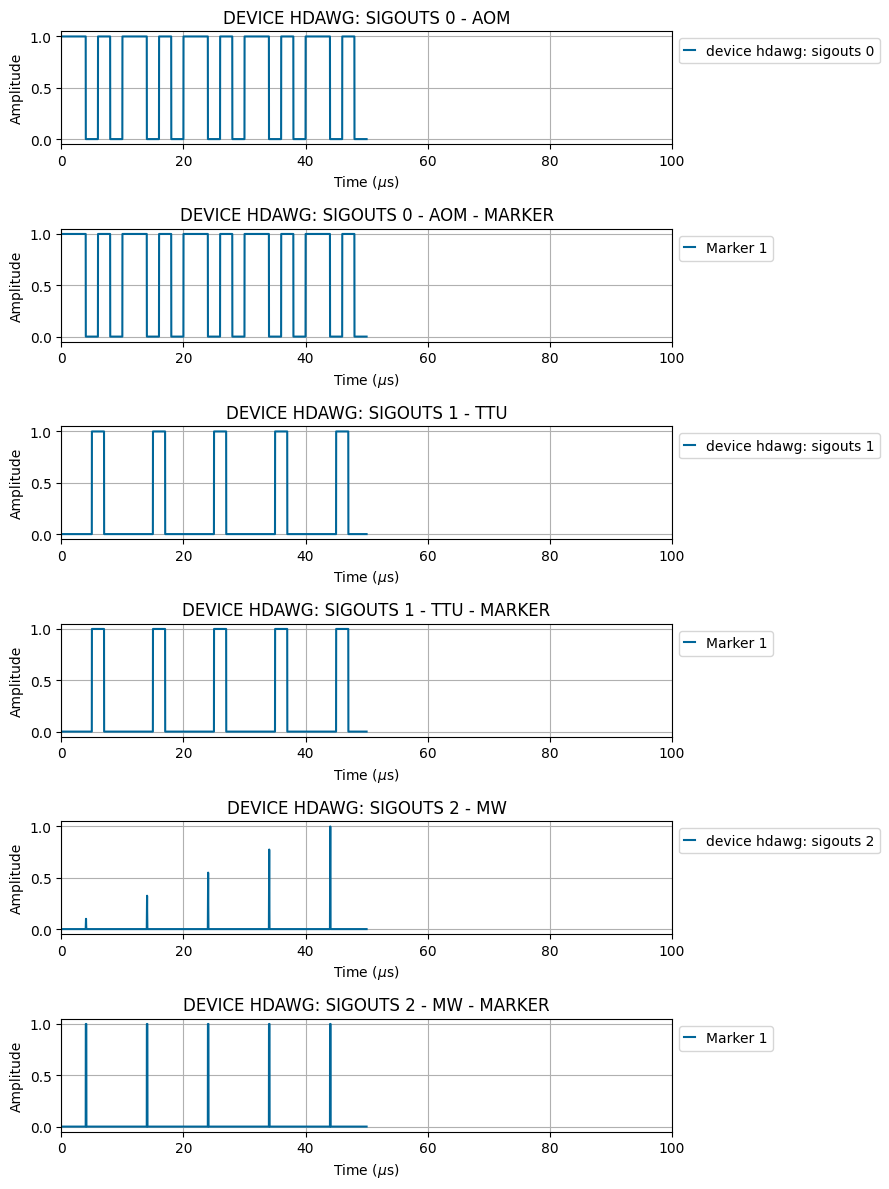

In [29]:
plot_simulation(compiled_rabi,start_time=0e-6,length=100e-6)

### 7b. Pulse sheet

`show_pulse_sheet` generates an interactive HTML timeline of all pulses, sections,
and sweep steps. Opens in the browser — useful for verifying the sequence structure
at a glance.

In [30]:
show_pulse_sheet("Ramsey_Experiment",compiled_rabi)

[2026.05.06 15:36:29.342] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.05.06 15:36:29.344] INFO    Starting LabOne Q Compiler run...
[2026.05.06 15:36:29.347] INFO    Schedule completed. [0.001 s]
[2026.05.06 15:36:29.352] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.05.06 15:36:29.353] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.05.06 15:36:29.354] WARNING /opt/miniconda3/lib/python3.13/site-packages/laboneq/core/utilities/seqc_compile.py:41: UserWarning: Installed version of zhinst-seqc-compiler is not compatible with this version of zhinst.core. Falling back to own version.
  elf, extra = zhinst.core.compile_seqc(

[2026.05.06 15:36:29.358] INFO    Finished LabOne Q Compiler run.
[2026.05.06 15:36:29.361] INFO    Writing html file to /Users/avishekc/Library/CloudS

/Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Supports/ISTA-Baykusheva/L1QScripts/Ramsey_Experiment_2026-05-06-15-36-29.html

## Section 8: Pulse Width Rabi

Instead of sweeping the MW drive amplitude, here we sweep the **length** (duration)
of the Gaussian MW pulse while keeping amplitude fixed at 1.0. This traces out
Rabi oscillations as a function of pulse area (proportional to pulse length for a
fixed Gaussian shape).

The sigma of `pulse_library.gaussian` scales as `length / 4` by default,
so the pulse shape remains self-similar across the sweep.

> **Note:** Pulse `length` is a compile-time timing parameter in LabOne Q — it cannot
> be passed as a `SweepParameter` like amplitude. Instead, we iterate over a NumPy array
> of concrete float values in Python and unroll the sweep into one section per step.
> Each step groups its AOM / TTU / MW sub-sections into a parent section so all three
> channels still run in parallel within a step.

**Sequence (identical to Amplitude Rabi — only the MW pulse duration changes):**
```
 t=0          4µs          6µs   8µs      10µs
  |            |            |     |         |
AOM  ▓▓▓▓▓▓▓▓▓▓            ▓▓▓▓▓▓▓
TTU                ▓▓▓▓▓▓▓▓▓▓
 MW           ▓ (Gaussian, amplitude=1.0, length swept 50 ns → 1 µs)
```

**Sweep:** Gaussian pulse length from 50 ns to 1000 ns, 20 linearly spaced points.

In [31]:
pulse_widths = np.linspace(50e-9, 1000e-9, 20)  # 20 steps: 50 ns to 1 µs

### 8a. Experiment Definition

For each pulse width value in `pulse_widths`, a parent section `step_i` is created
that contains three LEFT-aligned 10 µs child sections (AOM, TTU, MW). The child
sections run in parallel (different signals, no explicit ordering). The parent
sections run sequentially, implementing the sweep.

`pulse_library.gaussian(length=float(pw))` receives a concrete Python float per step,
so LabOne Q can generate waveforms at compile time.

| Parameter | Value |
|---|---|
| Amplitude | 1.0 (fixed) |
| Length | swept: 50 ns → 1000 ns (20 steps, numpy linspace) |
| Sigma (auto) | length / 4 (self-similar shape) |
| Section window | 10 µs per step (max content ≈ 5.1 µs — well within limit) |

In [32]:
def pulse_width_rabi(pulse_widths):

    exp_pw = Experiment(
        uid="Pulse Width Rabi",
        signals=[
            ExperimentSignal("AOM"),
            ExperimentSignal("TTU"),
            ExperimentSignal("MW"),
        ],
    )

    with exp_pw.acquire_loop_rt(
        count=1,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        for i, pw in enumerate(pulse_widths):
            # parent section keeps AOM/TTU/MW parallel within each step
            with exp_pw.section(uid=f"step_{i}", alignment=SectionAlignment.LEFT):

                with exp_pw.section(
                    uid=f"AOM_{i}",
                    alignment=SectionAlignment.LEFT,
                    length=10e-6,
                ):
                    exp_pw.play(
                        signal="AOM",
                        pulse=pulse_library.const(length=4000e-9, amplitude=1),
                        marker={"marker1": {"enable": True}},
                    )
                    exp_pw.delay(signal="AOM", time=2000e-9)
                    exp_pw.play(
                        signal="AOM",
                        pulse=pulse_library.const(length=2000e-9, amplitude=1),
                        marker={"marker1": {"enable": True}},
                    )

                with exp_pw.section(
                    uid=f"TTU_{i}",
                    alignment=SectionAlignment.LEFT,
                    length=10e-6,
                ):
                    exp_pw.delay(signal="TTU", time=5000e-9)
                    exp_pw.play(
                        signal="TTU",
                        pulse=pulse_library.const(length=2000e-9, amplitude=1),
                        marker={"marker1": {"enable": True}},
                    )

                with exp_pw.section(
                    uid=f"MW_{i}",
                    alignment=SectionAlignment.LEFT,
                    length=10e-6,
                ):
                    exp_pw.delay(signal="MW", time=4000e-9)
                    exp_pw.play(
                        signal="MW",
                        pulse=pulse_library.gaussian(length=float(pw)),
                        amplitude=1.0,
                        marker={"marker1": {"enable": True}},
                    )
                    exp_pw.delay(signal="MW", time=100e-9)

    return exp_pw

### 8b. Compile and Run

Re-apply calibration, build the experiment, set the signal map, compile and run.
Results are stored in `res_rabi_pw` (20 integration values, one per sweep step).

In [33]:
calibrate_devices(my_device_setup)

pw_rabi_exp = pulse_width_rabi(pulse_widths)
pw_rabi_exp.set_signal_map(signal_map)

compiled_rabi_pw = session.compile(pw_rabi_exp)
res_rabi_pw = session.run(compiled_rabi_pw)

[2026.05.06 15:36:33.362] INFO    Starting LabOne Q Compiler run...
[2026.05.06 15:36:33.364] INFO    Schedule completed. [0.000 s]
[2026.05.06 15:36:33.383] INFO    Code generation completed for all AWGs. [0.019 s]
[2026.05.06 15:36:33.384] INFO    Completed compilation step 1 of 1. [0.020 s]
[2026.05.06 15:36:33.386] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:33.387] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.06 15:36:33.387] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:33.388] INFO      device_hdawg     0        203           41          40    672000  
[2026.05.06 15:36:33.389] INFO      device_hdawg     1         84           21          20     25280  
[2026.05.06 15:36:33.389] INFO     ────────────────────────────────────────────────────────────────── 
[2026.05.06 15:36:33.390] INFO      TOTAL                     287           62         

### 8c. Visualise

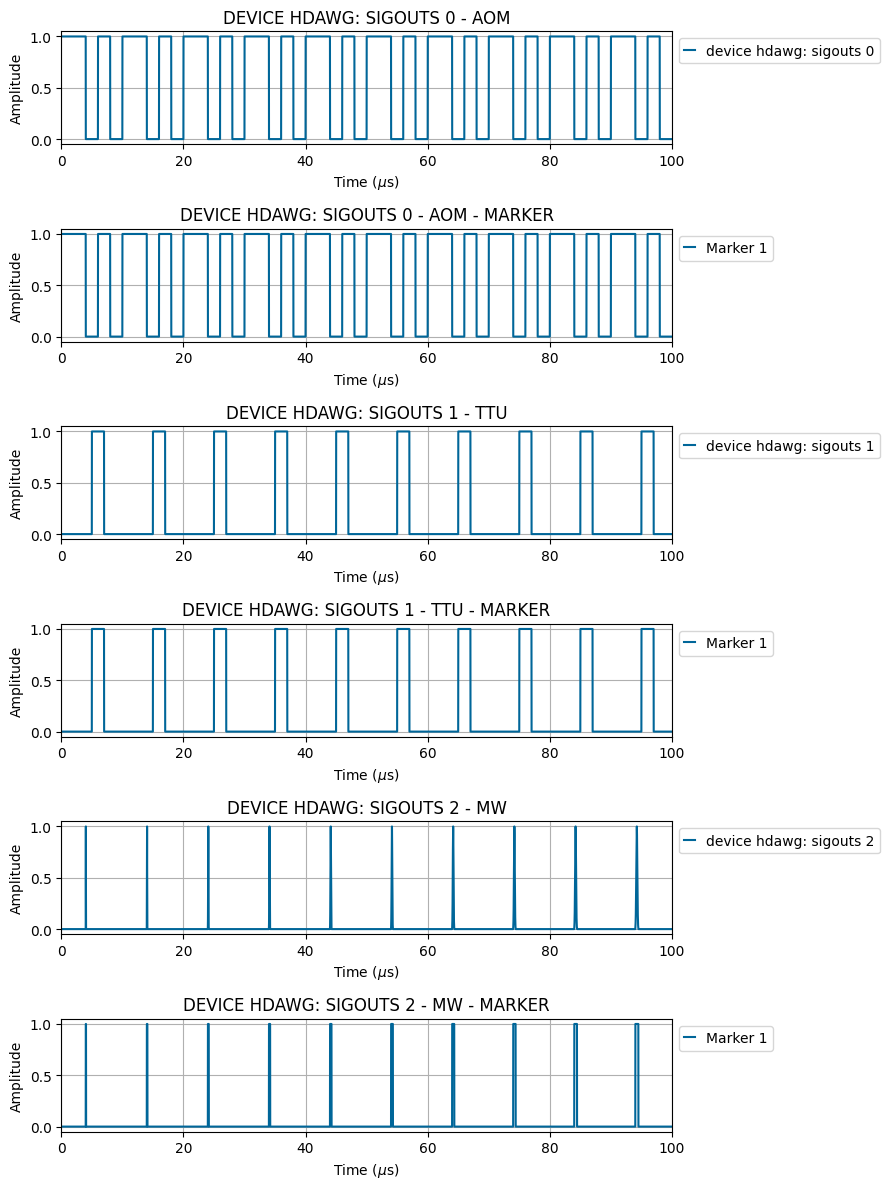

In [34]:
plot_simulation(compiled_rabi_pw, start_time=0e-6, length=100e-6)

In [35]:
show_pulse_sheet("Pulse_Width_Rabi", compiled_rabi_pw)

[2026.05.06 15:36:40.918] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.05.06 15:36:40.919] INFO    Starting LabOne Q Compiler run...
[2026.05.06 15:36:40.926] INFO    Schedule completed. [0.005 s]
[2026.05.06 15:36:40.939] INFO    Code generation completed for all AWGs. [0.013 s]
[2026.05.06 15:36:40.940] INFO    Completed compilation step 1 of 1. [0.020 s]
[2026.05.06 15:36:40.941] WARNING /opt/miniconda3/lib/python3.13/site-packages/laboneq/core/utilities/seqc_compile.py:41: UserWarning: Installed version of zhinst-seqc-compiler is not compatible with this version of zhinst.core. Falling back to own version.
  elf, extra = zhinst.core.compile_seqc(

[2026.05.06 15:36:40.947] INFO    Finished LabOne Q Compiler run.
[2026.05.06 15:36:40.949] INFO    Writing html file to /Users/avishekc/Library/CloudS

/Users/avishekc/Library/CloudStorage/OneDrive-ZurichInstrumentsAG/Documents/ZI Supports/ISTA-Baykusheva/L1QScripts/Pulse_Width_Rabi_2026-05-06-15-36-40.html